<a href="https://colab.research.google.com/github/umagujjula/Job_Market_Analysis/blob/main/Job_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

******Problem Statement******

****The objective of this project is to analyze job market data to identify in-demand skills, salary trends, and hiring patterns across different roles, companies, and locations using Python-based data analysis techniques.****

***Import Libraries***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/job_market_dataset.csv')

In [4]:
df.head(10)

,job_id,title,company,location,salary,experience,skills,posted_date
0,1,Full Stack Developer,Wipro,Hyderabad,16.66,0,"Excel, Power BI, SQL",5/19/2024
1,2,Data Engineer,Infosys,Delhi,19.39,6,"SQL, Python, Excel",3/9/2024
2,3,Full Stack Developer,Capgemini,Mumbai,13.57,7,"HTML, CSS, JavaScript",4/26/2024
3,4,Java Developer,Deloitte,Pune,15.54,4,"AWS, Docker, Kubernetes",2/13/2024
4,5,Software Engineer,Tech Mahindra,Mumbai,13.50,6,"Python, ML, SQL",3/12/2024
5,6,Software Engineer,Capgemini,Pune,18.36,6,"Excel, Power BI, SQL",5/26/2024
6,7,Frontend Developer,Accenture,Bangalore,3.19,3,"Python, Spark, SQL",5/29/2024
7,8,Data Engineer,Capgemini,Chennai,5.45,7,"Java, Spring Boot, SQL",2/17/2024
8,9,DevOps Engineer,Capgemini,Bangalore,12.87,5,"Python, Spark, SQL",3/14/2024
9,10,Data Analyst,Capgemini,Delhi,3.06,3,"SQL, Python, Excel",1/10/2024


In [5]:
df.tail()

,job_id,title,company,location,salary,experience,skills,posted_date
295,296,Data Scientist,Infosys,Bangalore,8.31,3,"HTML, CSS, JavaScript",3/13/2024
296,297,DevOps Engineer,Wipro,Hyderabad,12.24,3,"SQL, Python, Excel",2/21/2024
297,298,Business Analyst,HCL,Mumbai,7.32,7,"HTML, CSS, JavaScript",1/11/2024
298,299,Backend Developer,Tech Mahindra,Pune,16.87,2,"Python, ML, SQL",2/7/2024
299,300,DevOps Engineer,Accenture,Bangalore,5.07,4,"AWS, Docker, Kubernetes",4/1/2024


In [6]:
df.sample(5)

,job_id,title,company,location,salary,experience,skills,posted_date
118,119,Software Engineer,TCS,Mumbai,19.49,4,"Python, Spark, SQL",2/13/2024
202,203,DevOps Engineer,HCL,Chennai,11.70,1,"Python, ML, SQL",2/4/2024
254,255,Data Scientist,Infosys,Pune,5.59,2,"Java, Spring Boot, SQL",2/7/2024
195,196,Data Analyst,Accenture,Mumbai,8.80,6,"Python, ML, SQL",5/26/2024
173,174,Data Engineer,HCL,Mumbai,18.91,1,"SQL, Python, Excel",1/1/2024


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   job_id       300 non-null    int64  
 1   title        300 non-null    object 
 2   company      300 non-null    object 
 3   location     300 non-null    object 
 4   salary       300 non-null    float64
 5   experience   300 non-null    int64  
 6   skills       300 non-null    object 
 7   posted_date  300 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 18.9+ KB


In [8]:
df.columns

Index(['job_id', 'title', 'company', 'location', 'salary', 'experience',
       'skills', 'posted_date'],
      dtype='object')

In [9]:
df.shape

(300, 8)

In [10]:
df.isna()

,job_id,title,company,location,salary,experience,skills,posted_date
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

,0
job_id,0
title,0
company,0
location,0
salary,0
experience,0
skills,0
posted_date,0


In [12]:
df.describe()

,job_id,salary,experience
count,300.000000,300.000000,300.000000
mean,150.500000,11.521367,3.673333
std,86.746758,4.980910,2.300201
min,1.000000,3.010000,0.000000
25%,75.750000,7.080000,2.000000
50%,150.500000,11.720000,4.000000
75%,225.250000,15.767500,6.000000
max,300.000000,19.760000,7.000000


In [13]:
#  Remove Duplicates
df = df.drop_duplicates()
df

,job_id,title,company,location,salary,experience,skills,posted_date
0,1,Full Stack Developer,Wipro,Hyderabad,16.66,0,"Excel, Power BI, SQL",5/19/2024
1,2,Data Engineer,Infosys,Delhi,19.39,6,"SQL, Python, Excel",3/9/2024
2,3,Full Stack Developer,Capgemini,Mumbai,13.57,7,"HTML, CSS, JavaScript",4/26/2024
3,4,Java Developer,Deloitte,Pune,15.54,4,"AWS, Docker, Kubernetes",2/13/2024
4,5,Software Engineer,Tech Mahindra,Mumbai,13.50,6,"Python, ML, SQL",3/12/2024
...,...,...,...,...,...,...,...,...
295,296,Data Scientist,Infosys,Bangalore,8.31,3,"HTML, CSS, JavaScript",3/13/2024
296,297,DevOps Engineer,Wipro,Hyderabad,12.24,3,"SQL, Python, Excel",2/21/2024
297,298,Business Analyst,HCL,Mumbai,7.32,7,"HTML, CSS, JavaScript",1/11/2024
298,299,Backend Developer,Tech Mahindra,Pune,16.87,2,"Python, ML, SQL",2/7/2024


In [14]:
#  Fix datatype
df['salary'] = pd.to_numeric(df['salary'],errors = 'coerce')
df['experiece'] = pd.to_numeric(df['experience'],errors = 'coerce')

In [15]:
df

,job_id,title,company,location,salary,experience,skills,posted_date,experiece
0,1,Full Stack Developer,Wipro,Hyderabad,16.66,0,"Excel, Power BI, SQL",5/19/2024,0
1,2,Data Engineer,Infosys,Delhi,19.39,6,"SQL, Python, Excel",3/9/2024,6
2,3,Full Stack Developer,Capgemini,Mumbai,13.57,7,"HTML, CSS, JavaScript",4/26/2024,7
3,4,Java Developer,Deloitte,Pune,15.54,4,"AWS, Docker, Kubernetes",2/13/2024,4
4,5,Software Engineer,Tech Mahindra,Mumbai,13.50,6,"Python, ML, SQL",3/12/2024,6
...,...,...,...,...,...,...,...,...,...
295,296,Data Scientist,Infosys,Bangalore,8.31,3,"HTML, CSS, JavaScript",3/13/2024,3
296,297,DevOps Engineer,Wipro,Hyderabad,12.24,3,"SQL, Python, Excel",2/21/2024,3
297,298,Business Analyst,HCL,Mumbai,7.32,7,"HTML, CSS, JavaScript",1/11/2024,7
298,299,Backend Developer,Tech Mahindra,Pune,16.87,2,"Python, ML, SQL",2/7/2024,2


In [16]:
# Clean text columns
df['title'] = df['title'].str.strip()
df['skills'] = df['skills'].str.strip()

In [17]:
df

,job_id,title,company,location,salary,experience,skills,posted_date,experiece
0,1,Full Stack Developer,Wipro,Hyderabad,16.66,0,"Excel, Power BI, SQL",5/19/2024,0
1,2,Data Engineer,Infosys,Delhi,19.39,6,"SQL, Python, Excel",3/9/2024,6
2,3,Full Stack Developer,Capgemini,Mumbai,13.57,7,"HTML, CSS, JavaScript",4/26/2024,7
3,4,Java Developer,Deloitte,Pune,15.54,4,"AWS, Docker, Kubernetes",2/13/2024,4
4,5,Software Engineer,Tech Mahindra,Mumbai,13.50,6,"Python, ML, SQL",3/12/2024,6
...,...,...,...,...,...,...,...,...,...
295,296,Data Scientist,Infosys,Bangalore,8.31,3,"HTML, CSS, JavaScript",3/13/2024,3
296,297,DevOps Engineer,Wipro,Hyderabad,12.24,3,"SQL, Python, Excel",2/21/2024,3
297,298,Business Analyst,HCL,Mumbai,7.32,7,"HTML, CSS, JavaScript",1/11/2024,7
298,299,Backend Developer,Tech Mahindra,Pune,16.87,2,"Python, ML, SQL",2/7/2024,2


*******Exploratory Data Analysis(EDA)*******

****Top Job Roles****

In [18]:
df['title'].unique()

array(['Full Stack Developer', 'Data Engineer', 'Java Developer',
       'Software Engineer', 'Frontend Developer', 'DevOps Engineer',
       'Data Analyst', 'Business Analyst', 'Data Scientist',
       'Backend Developer'], dtype=object)

In [19]:
top_roles = df['title'].value_counts()

In [20]:
top_roles

,count
title,
Software Engineer,37
Data Engineer,34
Data Analyst,34
DevOps Engineer,32
Full Stack Developer,31
Frontend Developer,30
Data Scientist,28
Business Analyst,28
Java Developer,27


****Average salary per role****

In [21]:
avg_salary_role = df.groupby('title')['salary'].mean().sort_values(ascending = False)

In [22]:
avg_salary_role

,salary
title,
Data Analyst,13.698824
Java Developer,13.660000
Backend Developer,12.097368
Full Stack Developer,11.534839
Data Engineer,11.259706
Frontend Developer,11.030000
Software Engineer,10.935676
DevOps Engineer,10.750937
Business Analyst,10.332143


****Jobs by Location****

In [23]:
jobs_location = df['location'].value_counts()

In [24]:
jobs_location

,count
location,
Pune,56
Chennai,55
Delhi,53
Mumbai,52
Bangalore,43
Hyderabad,41


****Experience vs Salary****

In [25]:
exp_sal = df.groupby('experience')['salary'].mean()

In [26]:
exp_sal

,salary
experience,
0,11.275926
1,12.443696
2,13.538571
3,10.003125
4,10.957097
5,11.175882
6,12.594500
7,10.801957


****Top Companies Hiring****

In [27]:
top_companies = df['company'].value_counts().head(10)

In [28]:
top_companies

,count
company,
Capgemini,43
Deloitte,41
Tech Mahindra,40
Wipro,38
TCS,37
HCL,35
Infosys,34
Accenture,32


****Skills Analysis****

In [29]:
 # Split skills into list
df['skills'] = df['skills'].str.split(',')

In [30]:
# Explode rows
skills_df = df.explode('skills')

In [31]:
#  Clean
skills_df['skills'] = skills_df['skills'].str.strip()

In [32]:
#  Count skills
top_skills = skills_df['skills'].value_counts()

In [33]:
top_skills.head(10)

,count
skills,
SQL,196
Python,116
Excel,87
JavaScript,73
Power BI,45
HTML,42
CSS,42
ML,39
Spring Boot,35


****Role Comparision ( Data vs Developer )****

In [34]:
def role_category(title):
    if "Data" in title:
        return "Data Roles"
    else:
        return "Development Roles"

df['role_type'] = df['title'].apply(role_category)

df['role_type'].value_counts()

,count
role_type,
Development Roles,204
Data Roles,96


*******Visualization*******

***Top Skills***

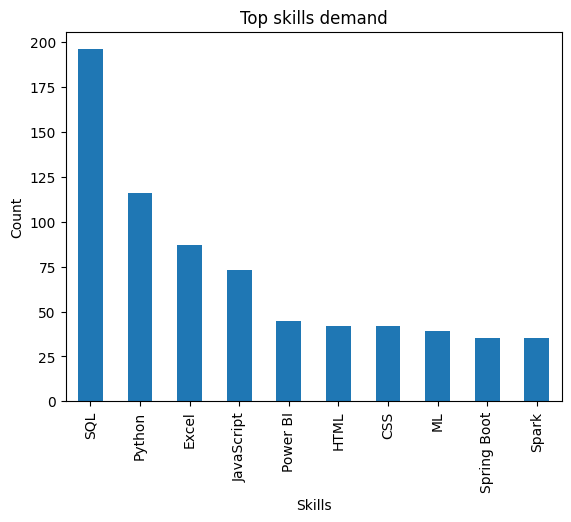

In [35]:
top_skills.head(10).plot(kind = 'bar')
plt.title('Top skills demand')
plt.xlabel('Skills')
plt.ylabel('Count')
plt.show()

***Top Job Roles***

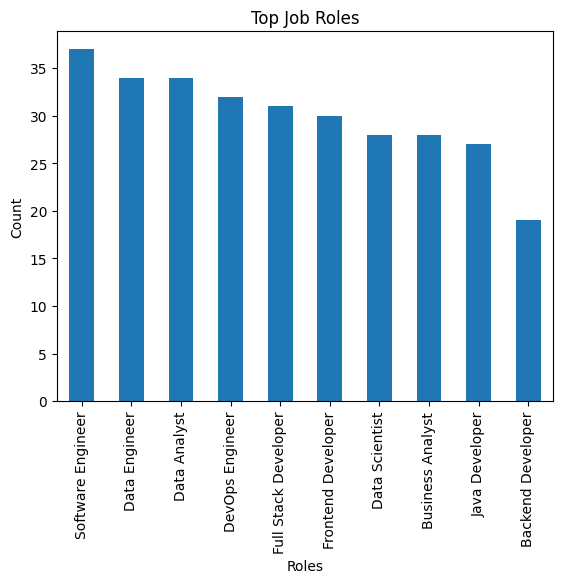

In [36]:
top_roles.head(10).plot(kind = 'bar')
plt.title('Top Job Roles')
plt.xlabel('Roles')
plt.ylabel('Count')
plt.show()

***Salary vs Experience***

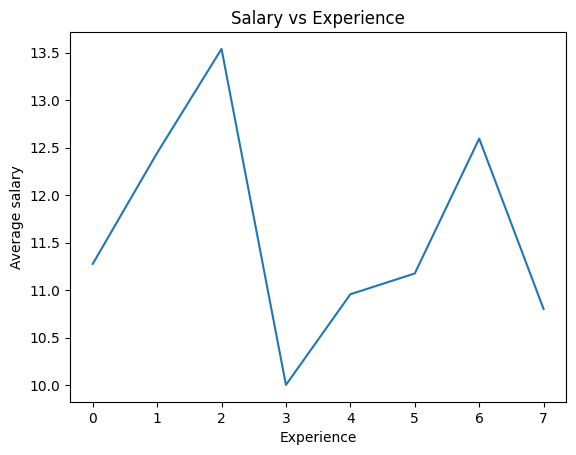

In [37]:
exp_sal.plot()
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Average salary')
plt.show()

***Jobs by Location***

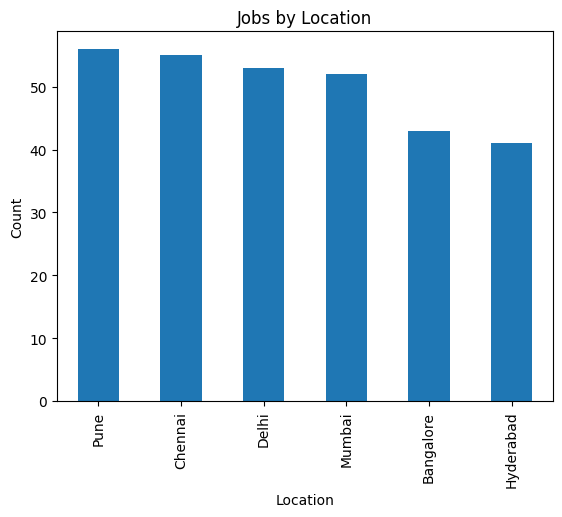

In [38]:
jobs_location.head(10).plot(kind = 'bar')
plt.title('Jobs by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

***Salary Distribution***

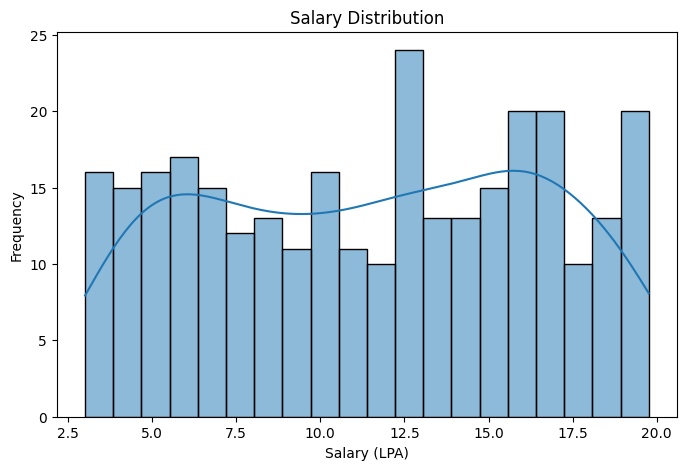

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary'], bins=20, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary (LPA)")
plt.ylabel("Frequency")
plt.show()

***Salary by Role***

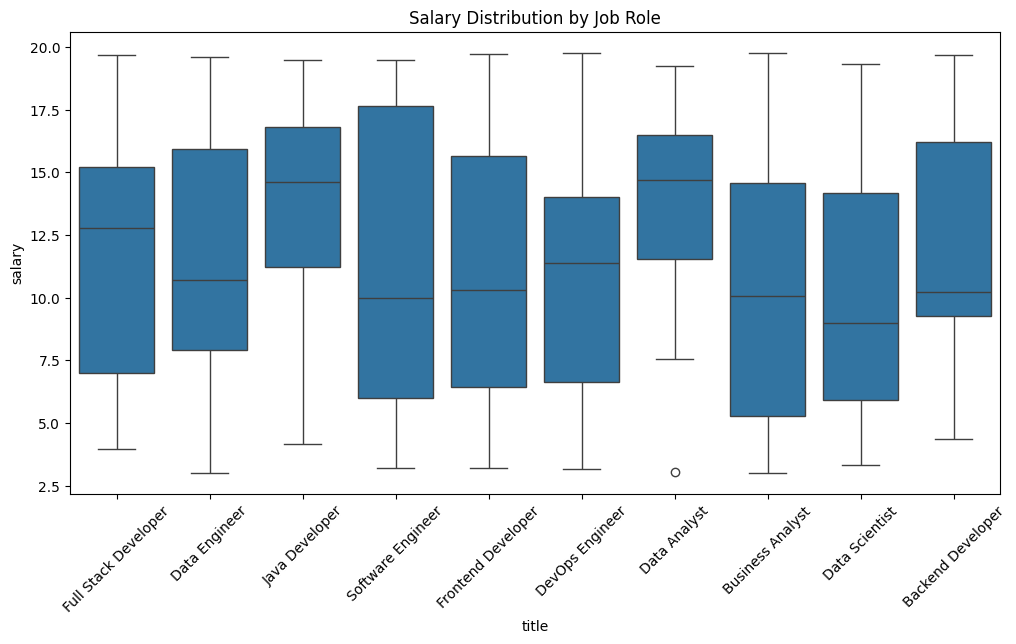

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(x='title', y='salary', data=df)
plt.xticks(rotation=45)
plt.title("Salary Distribution by Job Role")
plt.show()

****Heatmap(Correlation Matrix)****

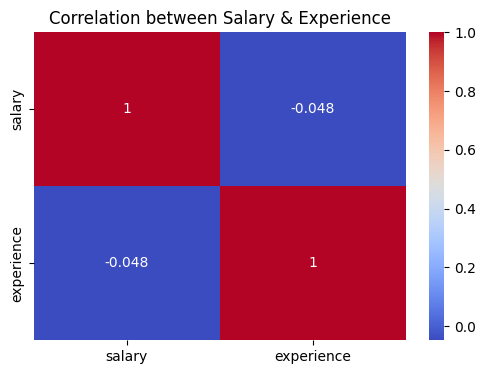

In [41]:
plt.figure(figsize=(6,4))
corr = df[['salary','experience']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Salary & Experience")
plt.show()

****Top Job Roles****

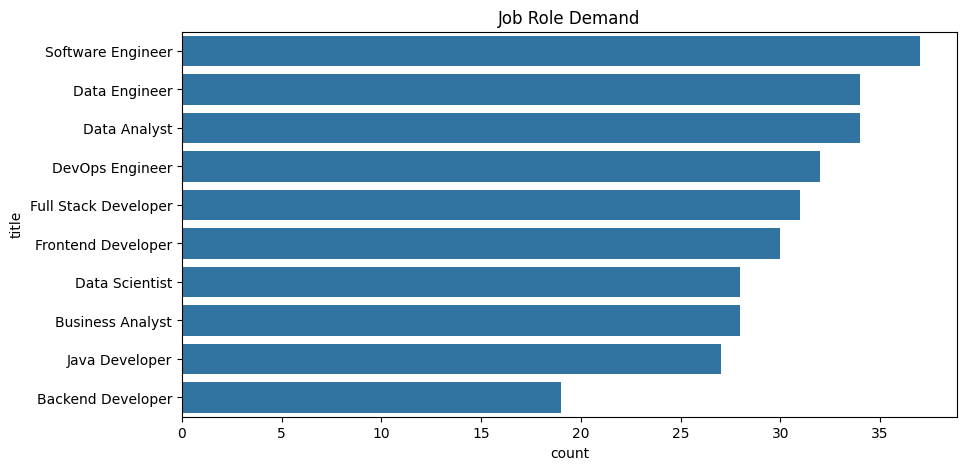

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(y='title', data=df, order=df['title'].value_counts().index)
plt.title("Job Role Demand")
plt.show()

****SAlary vs Experience (scatter plot)****

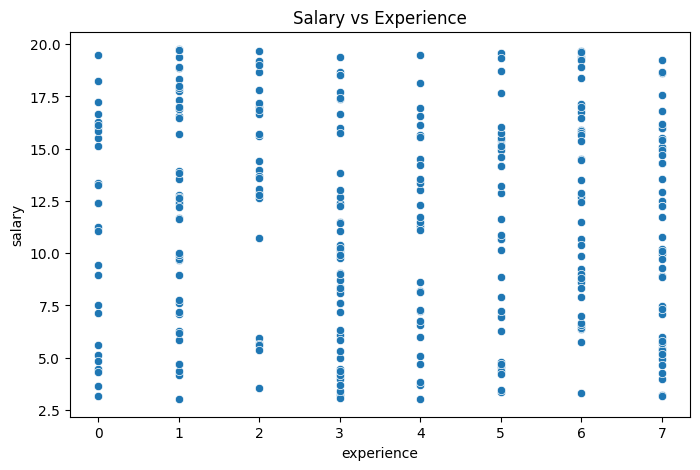

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='experience', y='salary', data=df)
plt.title("Salary vs Experience")
plt.show()

****Jobs trend over time****

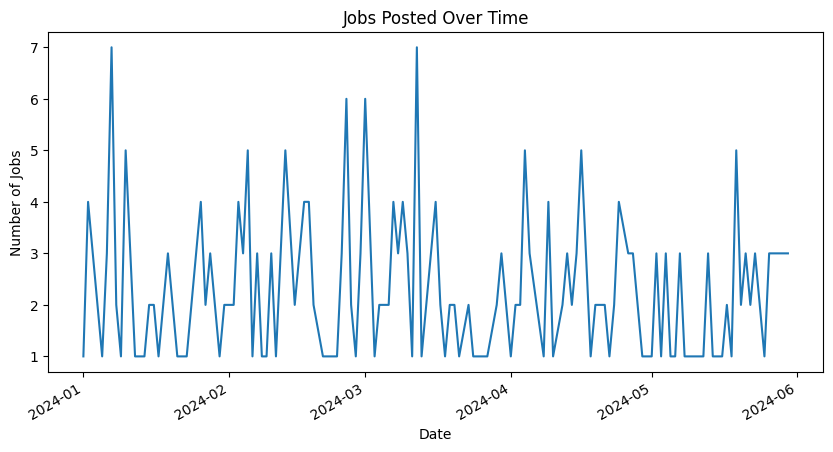

In [44]:
df['posted_date'] = pd.to_datetime(df['posted_date'])

jobs_trend = df.groupby('posted_date').size()

plt.figure(figsize=(10,5))
jobs_trend.plot()
plt.title("Jobs Posted Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Jobs")
plt.show()

****Salary vs Experience by role****

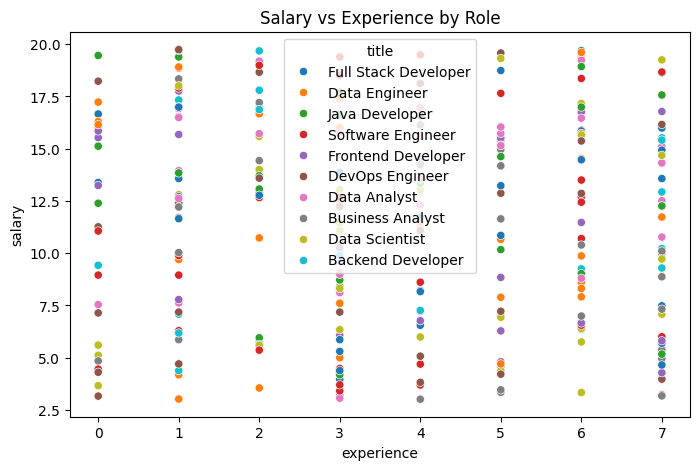

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='experience', y='salary', hue='title', data=df)
plt.title("Salary vs Experience by Role")
plt.show()

******INSIGHTS******

Python and SQL are the most in-demand skills across roles

JavaScript, Java, and cloud tools (AWS, Docker) dominate developer roles

Excel and Power BI are still essential for data analyst roles

Multi-skill combinations (e.g., Python + SQL) appear more frequently than single skills

Software/Developer roles appear more frequently than data roles

Among data roles, Data Analyst positions dominate over Data Scientist

Emerging roles like DevOps Engineer show steady demand

Salary increases with experience (clear upward trend)

Data Scientist and DevOps roles tend to have higher average salaries

Entry-level salaries are relatively lower but increase significantly after 2–3 years

Bangalore and Hyderabad have the highest number of job openings

Other cities like Pune and Chennai show moderate demand

Large IT companies (TCS, Infosys, Accenture, etc.) dominate hiring

Hiring is distributed across multiple companies rather than concentrated in one

Most jobs require 0–3 years experience

Fewer roles are available for very high experience levels

Roles requiring advanced tools (ML, Cloud, DevOps) tend to have higher salaries

Basic tools (Excel) are common but not strongly linked to high salaries

Data roles → More analytical skills (Python, SQL, Excel)

Development roles → More technical stack (Java, JS, DevOps tools)



***Save Work***

In [46]:
df.to_csv("cleaned_jobs.csv", index=False)

In [47]:
df.head()

,job_id,title,company,location,salary,experience,skills,posted_date,experiece,role_type
0,1,Full Stack Developer,Wipro,Hyderabad,16.66,0,"[Excel, Power BI, SQL]",2024-05-19,0,Development Roles
1,2,Data Engineer,Infosys,Delhi,19.39,6,"[SQL, Python, Excel]",2024-03-09,6,Data Roles
2,3,Full Stack Developer,Capgemini,Mumbai,13.57,7,"[HTML, CSS, JavaScript]",2024-04-26,7,Development Roles
3,4,Java Developer,Deloitte,Pune,15.54,4,"[AWS, Docker, Kubernetes]",2024-02-13,4,Development Roles
4,5,Software Engineer,Tech Mahindra,Mumbai,13.50,6,"[Python, ML, SQL]",2024-03-12,6,Development Roles
